# Khám phá Dữ liệu (EDA) & Tiền xử lý
## 1. Giới thiệu Đề Tài

### Bài toán Churn là gì?
Churn (rời bỏ) là hiện tượng khách hàng ngừng sử dụng dịch vụ.
Trong lĩnh vực gym/fitness, một học viên được coi là 'churn' khi không quay lại tập sau **78 ngày**.

### Vì sao cần dự đoán Churn?
- Chi phí giữ chân khách hàng cũ **thấp hơn 5–7 lần** so với thu hút khách mới.
- Dự đoán sớm giúp triển khai chiến lược retention kịp thời.
- Tối ưu hóa doanh thu cho phòng gym.

### Mục tiêu đề tài
Xây dựng mô hình Machine Learning dự đoán học viên có khả năng nghỉ tập để hỗ trợ quản lý gym đưa ra quyết định can thiệp.
**Metric đánh giá chính:** Macro F1-Score (vì dữ liệu mất cân bằng: ~78% Churn)

In [77]:
# === PHẦN 2: MÔ TẢ DATASET ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
df = pd.read_csv('../dataMaster/gym_churn_master_final.csv')

print('=' * 50)
print('TỔNG QUAN DỮ LIỆU')
print('=' * 50)
print(f'Số lượng học viên (rows): {df.shape[0]:,}')
print(f'Số lượng đặc trưng (columns): {df.shape[1]}')
print('\nTỷ lệ Churn:')
print(df['is_churn'].value_counts(normalize=True).rename({0:'Ở lại', 1:'Nghỉ tập'}))

TỔNG QUAN DỮ LIỆU
Số lượng học viên (rows): 6,320
Số lượng đặc trưng (columns): 18

Tỷ lệ Churn:
is_churn
Nghỉ tập    0.781329
Ở lại       0.218671
Name: proportion, dtype: float64


In [78]:
# Feature description table
feature_desc = {
    'Feature': list(df.columns),
    'Dtype': [str(df[c].dtype) for c in df.columns],
    'Null Count': [df[c].isnull().sum() for c in df.columns]
}
pd.DataFrame(feature_desc)

,Feature,Dtype,Null Count
0,short_p_id,int64,0
1,total_visits,float64,0
2,max_streak,float64,0
3,avg_time_lag,float64,0
4,seniority_days,int64,0
5,visits_per_month,float64,0
6,recency,int64,0
7,weekend_ratio,float64,0
8,attendance_momentum,float64,0
9,attendance_variance,float64,0


In [79]:
# Thống kê mô tả
df.describe().T.style.format('{:.2f}').set_caption('Thống kê mô tả các features số')

,count,mean,std,min,25%,50%,75%,max
short_p_id,6320.00,30104.88,17213.06,3.00,15200.00,30099.00,45136.00,59177.00
total_visits,6320.00,158.27,132.31,1.00,62.00,117.00,216.00,841.00
max_streak,6320.00,6.15,7.36,0.00,3.00,5.00,6.00,161.00
avg_time_lag,6320.00,25.62,49.14,1.03,4.31,10.51,26.18,681.50
seniority_days,6320.00,689.30,249.58,0.00,479.00,670.00,907.00,1126.00
visits_per_month,6320.00,7.03,5.09,0.03,3.08,5.67,9.73,30.00
recency,6320.00,220.00,204.42,0.00,95.00,177.00,255.00,1127.00
weekend_ratio,6320.00,0.21,0.15,0.00,0.11,0.20,0.28,1.00
attendance_momentum,6320.00,0.95,0.51,0.04,1.00,1.00,1.00,9.00
attendance_variance,6320.00,26.89,41.43,0.00,4.78,13.04,31.29,624.65


In [80]:
# === PHẦN 3: KIỂM TRA CHẤT LƯỢNG DỮ LIỆU ===
print('=== KIỂM TRA MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Số lượng null': missing, 'Phần trăm (%)': missing_pct})
missing_df = missing_df[missing_df['Số lượng null'] > 0]

if len(missing_df) == 0:
    print('✅ Không có missing values trong dataset!')
else:
    print(missing_df)

=== KIỂM TRA MISSING VALUES ===
✅ Không có missing values trong dataset!


In [81]:
print('\n=== KIỂM TRA OUTLIERS (IQR Method) ===')
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c not in ['is_churn', 'recency']]

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'Feature': col, 'Số outliers': n_outliers, '%': round(n_outliers/len(df)*100, 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('Số outliers', ascending=False)
print(outlier_df.to_string(index=False))
print('\n⚠️ Lưu ý: XGBoost và Random Forest không nhạy cảm với outliers.\n          Chỉ cần xử lý outliers (nếu cần) cho LR, SVM, MLP.')


=== KIỂM TRA OUTLIERS (IQR Method) ===
                 Feature  Số outliers     %
     attendance_momentum         1068 16.90
              max_streak          667 10.55
            avg_time_lag          616  9.75
     attendance_variance          538  8.51
         customer_postal          383  6.06
population_density_sq_mi          373  5.90
            total_visits          299  4.73
                  income          215  3.40
           weekend_ratio          177  2.80
                att_rate          173  2.74
        visits_per_month          162  2.56
                     age           46  0.73
          seniority_days            0  0.00
              short_p_id            0  0.00

⚠️ Lưu ý: XGBoost và Random Forest không nhạy cảm với outliers.
          Chỉ cần xử lý outliers (nếu cần) cho LR, SVM, MLP.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23712\4293990873.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_churn', data=df, palette=['#4ECDC4', '#FF6B6B'], ax=axes[1])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23712\4293990873.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Ở lại (0)', 'Churn (1)'])


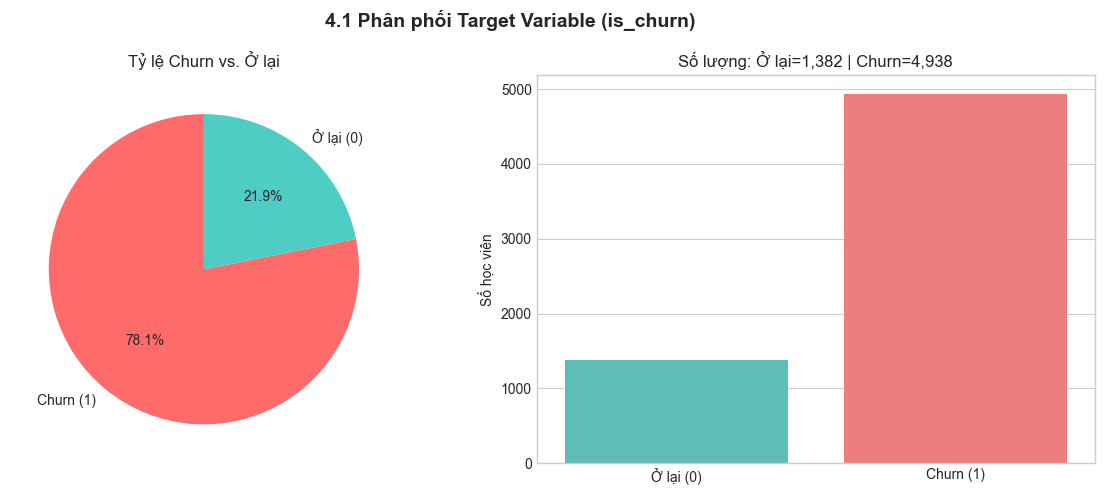

In [82]:
# === PHẦN 4: EXPLORATORY DATA ANALYSIS (EDA) ===
# 4.1 Phân phối Target Variable (Class Imbalance)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df['is_churn'].value_counts()
axes[0].pie(churn_counts, labels=['Churn (1)', 'Ở lại (0)'], autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[0].set_title('Tỷ lệ Churn vs. Ở lại')

sns.countplot(x='is_churn', data=df, palette=['#4ECDC4', '#FF6B6B'], ax=axes[1])
axes[1].set_xticklabels(['Ở lại (0)', 'Churn (1)'])
axes[1].set_title(f'Số lượng: Ở lại={churn_counts[0]:,} | Churn={churn_counts[1]:,}')
axes[1].set_xlabel(''); axes[1].set_ylabel('Số học viên')

plt.suptitle('4.1 Phân phối Target Variable (is_churn)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

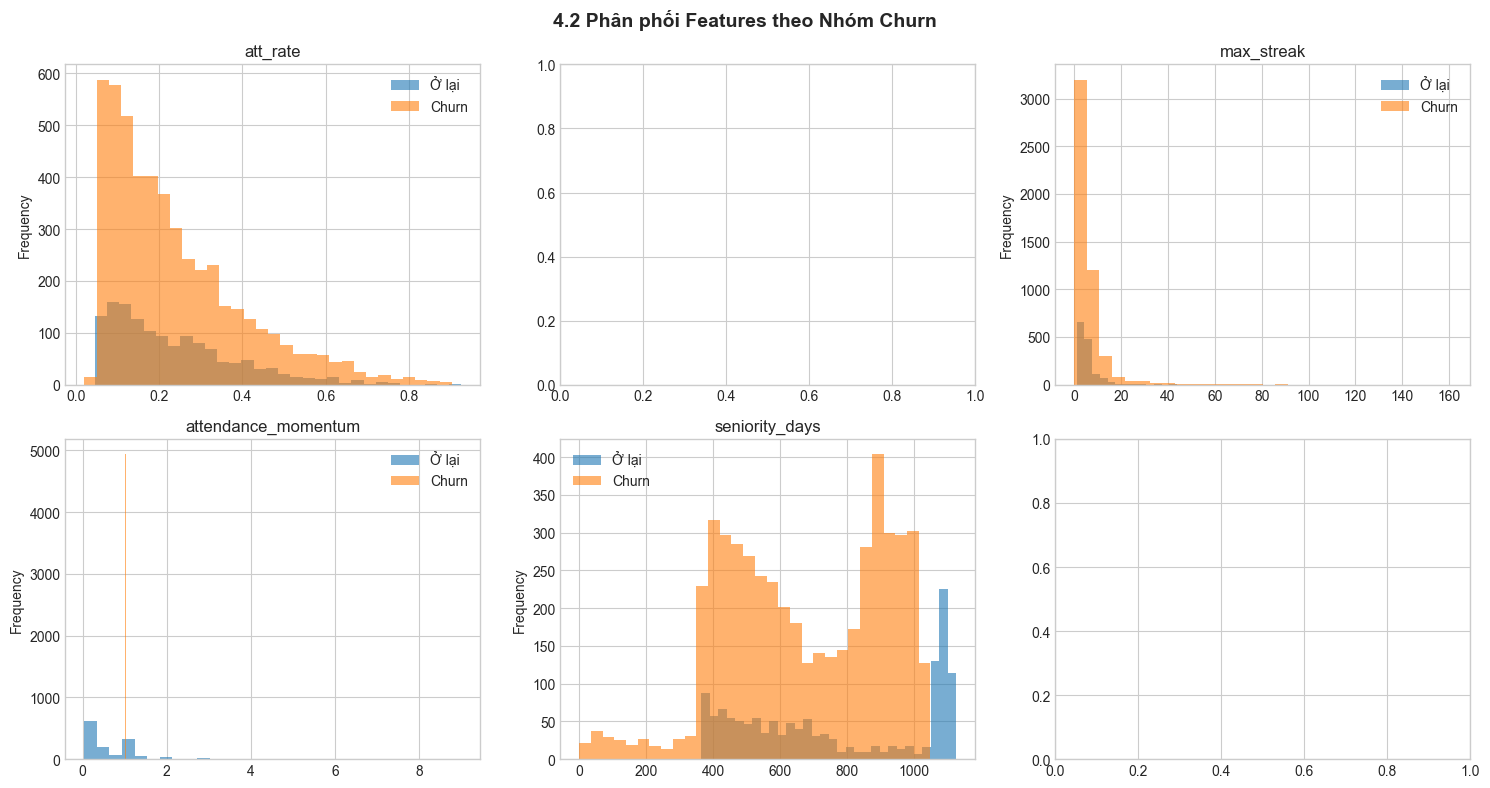

In [83]:
# 4.2 Phân phối các features số quan trọng
numeric_features = ['att_rate', 'avg_gap', 'max_streak', 'attendance_momentum', 'seniority_days']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    if feat in df.columns:
        df.groupby('is_churn')[feat].plot(kind='hist', ax=axes[i], alpha=0.6, bins=30, legend=True)
        axes[i].set_title(f'{feat}')
        axes[i].legend(['Ở lại', 'Churn'])

plt.suptitle('4.2 Phân phối Features theo Nhóm Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

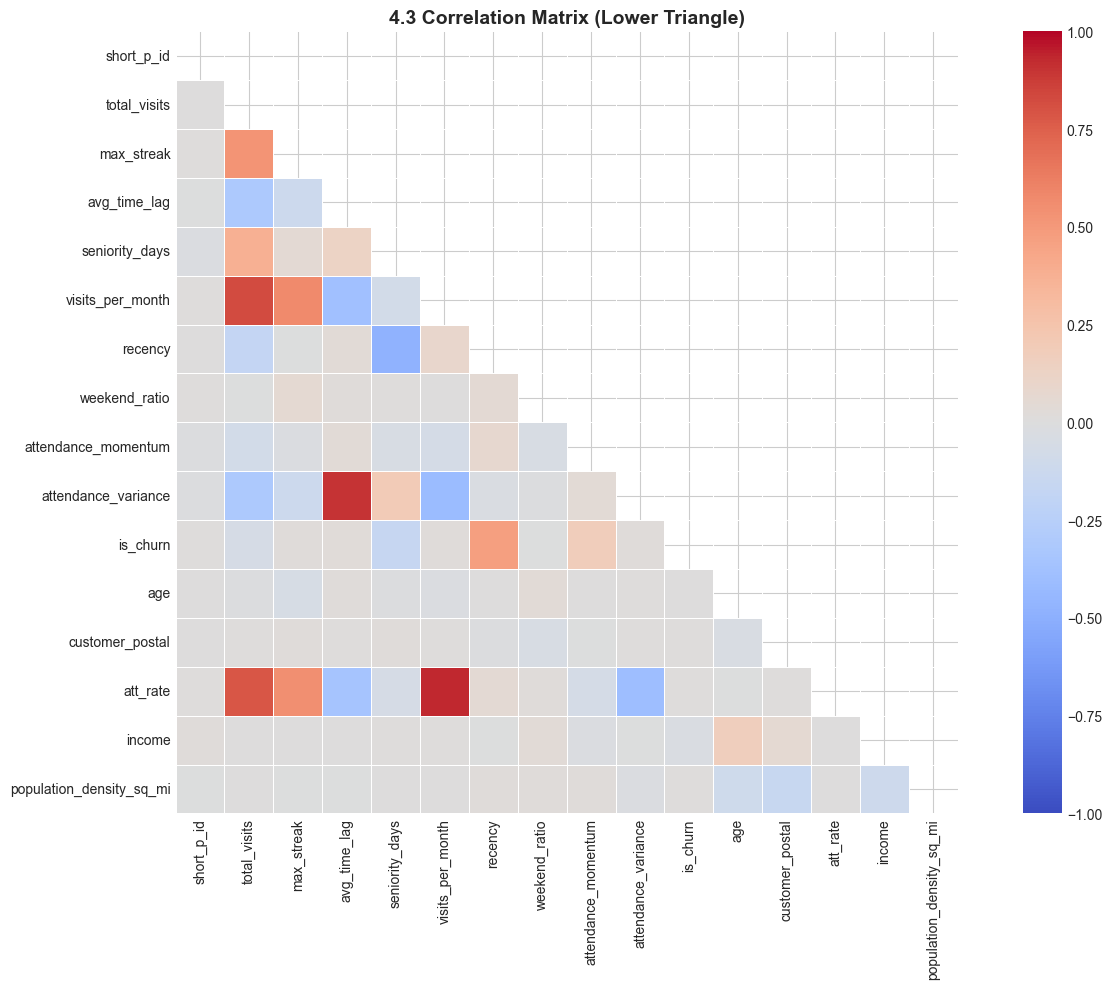


Top 10 features tương quan với is_churn:
recency                     0.470530
attendance_momentum         0.175189
seniority_days              0.158073
total_visits                0.056448
avg_time_lag                0.031022
income                      0.024302
max_streak                  0.022494
visits_per_month            0.021721
attendance_variance         0.015895
population_density_sq_mi    0.012400
Name: is_churn, dtype: float64


In [84]:
# 4.3 Correlation Matrix
plt.figure(figsize=(14, 10))
df_numeric = df.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('4.3 Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

corr_with_target = df_numeric.corr()['is_churn'].drop('is_churn').abs().sort_values(ascending=False)
print('\nTop 10 features tương quan với is_churn:')
print(corr_with_target.head(10))

### 📊 5. Key Insights từ EDA
1. **Class Imbalance nghiêm trọng**: ~78% là Churn → cần dùng `class_weight` (Logistic Regression, SVM, MLP) hoặc `scale_pos_weight` (XGBoost) khi huấn luyện.
2. **`att_rate` (tỷ lệ chuyên cần)** có tương quan mạnh với churn - học viên có att_rate thấp dễ nghỉ hơn.
3. **`avg_gap` (khoảng cách trung bình giữa các buổi tập)** - gap càng lớn, churn rate càng cao.
4. **`recency` bị loại** vì gây Data Leakage (is_churn được định nghĩa từ recency > 78).
5. Các biến behavioral (`max_streak`, `attendance_momentum`) là tín hiệu rất tốt để phân biệt 2 nhóm.